# Аналіз розподілу енергетичних витрат

## Завдання
Використати бібліотеки `numpy` та `scipy.stats` для створення набору даних про енергетичні витрати з нормальним та експоненціальним розподілами. Побудувати графіки для порівняння цих розподілів та провести їх базовий аналіз. Код має бути написаний у стилі об'єктно-орієнтованого програмування (ООП).

## Суть завдання
Мета завдання полягає у моделюванні даних, які описують витрати енергії:
- **Нормальний розподіл** використовується для моделювання ситуацій, де витрати зазвичай групуються навколо певного середнього значення.
- **Експоненціальний розподіл** підходить для моделювання подій, які відбуваються рідше зі збільшенням їх величини (наприклад, екстремальні пікові навантаження).

За допомогою створеного ООП класу проводиться генерація цих даних, їх візуалізація та обчислення основних статистичних метрик для порівняння.

## Опис результатів
Після виконання коду ви отримаєте:
1. **Графіки**: Два гістограми з накладеними теоретичними кривими щільності ймовірності. Нормальний розподіл матиме форму симетричного "дзвона", що вказує на концентрацію даних навколо середнього. Експоненціальний розподіл матиме різкий спад, де більшість даних згрупована на початку, а великі значення зустрічаються рідко.
2. **Аналітика в консолі**: Виведення середнього значення, дисперсії та медіани. Це дозволяє чисельно перевірити і порівняти характеристики кожного з масивів змодельованих енергетичних витрат.

## Приклади реального використання
1. **Нормальний розподіл в енергетиці**: Чудово працює для прогнозування та аналізу базового споживання енергії цілим містом або великою фабрикою. Коли багато різних споживачів працюють незалежно, їхнє сумарне споживання зазвичай набуває форму нормального розподілу (через центральну граничну теорему).
2. **Експоненціальний розподіл в енергетиці**: Використовується при оцінці ризиків та надійності обладнання. Наприклад, це моделювання часу роботи трансформаторів до виникнення першої поломки або ж оцінки інтервалів часу між критичними відключеннями у мережі.


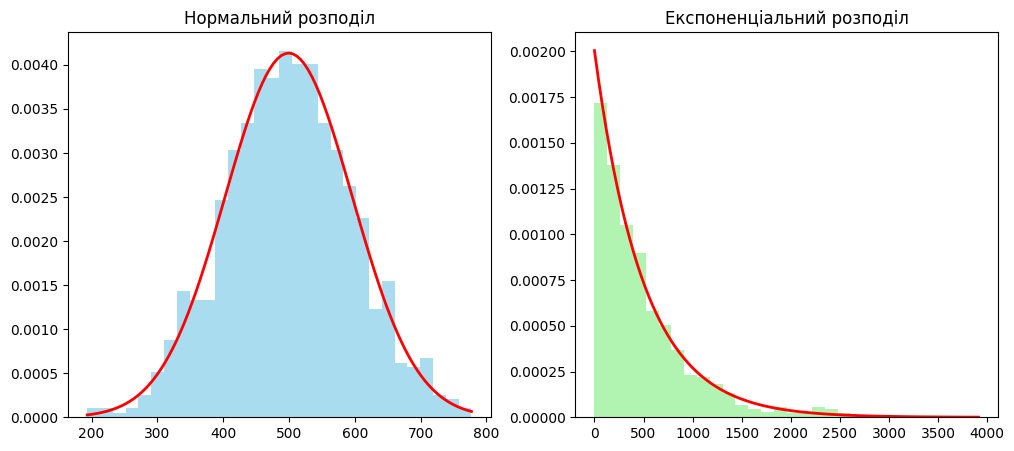

Нормальний розподіл:
  Середнє (Mean): 499.54
  Дисперсія (Variance): 9315.12
  Медіана (Median): 501.07
Експоненціальний розподіл:
  Середнє (Mean): 498.79
  Дисперсія (Variance): 257366.32
  Медіана (Median): 347.22



In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

class EnergyCostAnalyzer:
    def __init__(self, sample_size):
        self.sample_size = sample_size
        self.normal_data = np.array([])
        self.exponential_data = np.array([])

    def generate_data(self, norm_loc, norm_scale, exp_scale):
        self.normal_data = stats.norm.rvs(loc=norm_loc, scale=norm_scale, size=self.sample_size)
        self.exponential_data = stats.expon.rvs(scale=exp_scale, size=self.sample_size)

    def plot_distributions(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].hist(self.normal_data, bins=30, density=True, alpha=0.7, color='skyblue')
        x_norm = np.linspace(self.normal_data.min(), self.normal_data.max(), 100)
        axes[0].plot(x_norm, stats.norm.pdf(x_norm, np.mean(self.normal_data), np.std(self.normal_data)), 'r-', lw=2)
        axes[0].set_title("Нормальний розподіл")

        axes[1].hist(self.exponential_data, bins=30, density=True, alpha=0.7, color='lightgreen')
        x_exp = np.linspace(self.exponential_data.min(), self.exponential_data.max(), 100)
        axes[1].plot(x_exp, stats.expon.pdf(x_exp, scale=np.mean(self.exponential_data)), 'r-', lw=2)
        axes[1].set_title("Експоненціальний розподіл")

        plt.show()

    def analyze(self):
        analysis_result = {
            "Нормальний розподіл": {
                "Середнє (Mean)": np.mean(self.normal_data),
                "Дисперсія (Variance)": np.var(self.normal_data),
                "Медіана (Median)": np.median(self.normal_data)
            },
            "Експоненціальний розподіл": {
                "Середнє (Mean)": np.mean(self.exponential_data),
                "Дисперсія (Variance)": np.var(self.exponential_data),
                "Медіана (Median)": np.median(self.exponential_data)
            }
        }
        
        for dist_name, metrics in analysis_result.items():
            print(f"{dist_name}:")
            for metric_name, value in metrics.items():
                print(f"  {metric_name}: {value:.2f}")
        print()

analyzer = EnergyCostAnalyzer(sample_size=1000)
analyzer.generate_data(norm_loc=500, norm_scale=100, exp_scale=500)
analyzer.plot_distributions()
analyzer.analyze()
